In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('car_sales.csv')
print(df.shape)

(4345, 9)


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4345 non-null   str    
 1   Price         4173 non-null   float64
 2   Body          4345 non-null   str    
 3   Mileage       4345 non-null   int64  
 4   EngineV       4195 non-null   float64
 5   Engine Type   4345 non-null   str    
 6   Registration  4345 non-null   str    
 7   Year          4345 non-null   int64  
 8   Model         4345 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 305.6 KB
None


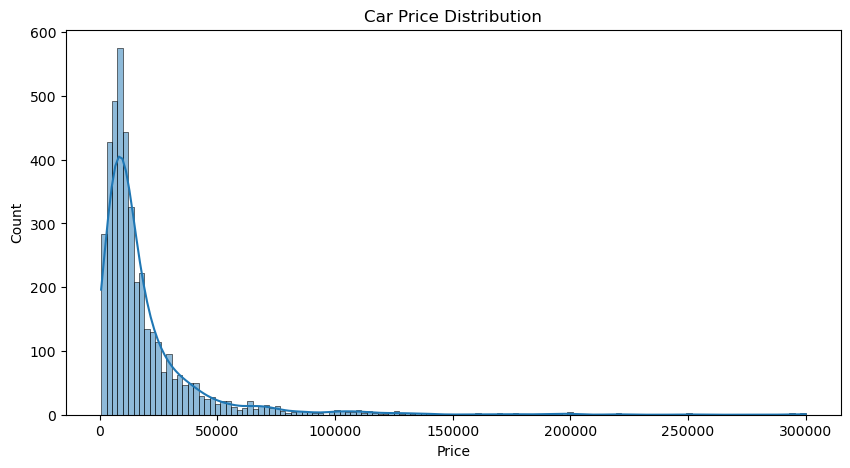

In [4]:
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True)
plt.title('Car Price Distribution')
plt.savefig('price_distribution.png', dpi = 150, bbox_inches='tight')
plt.show()

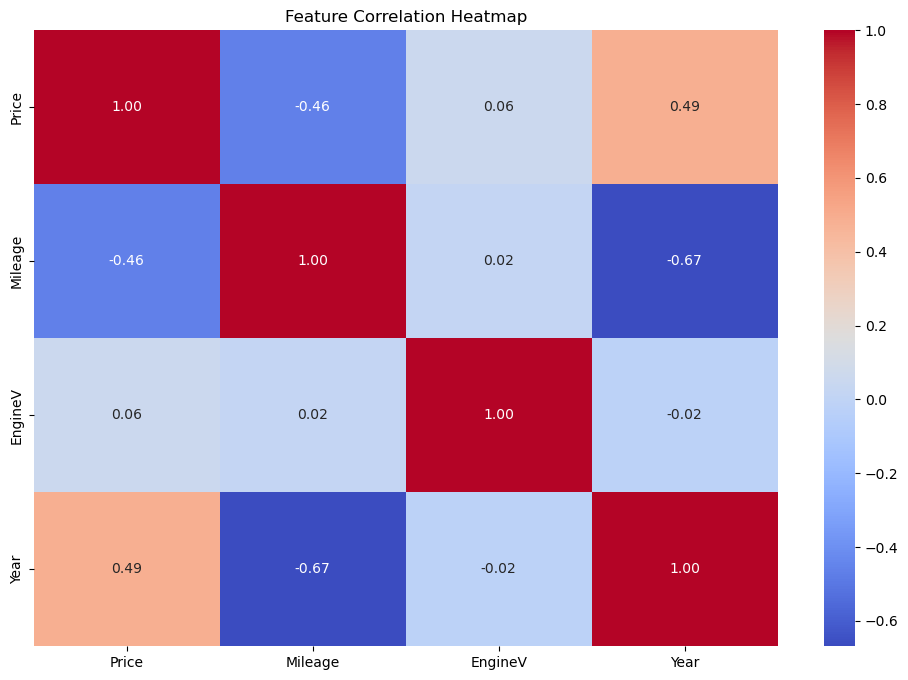

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

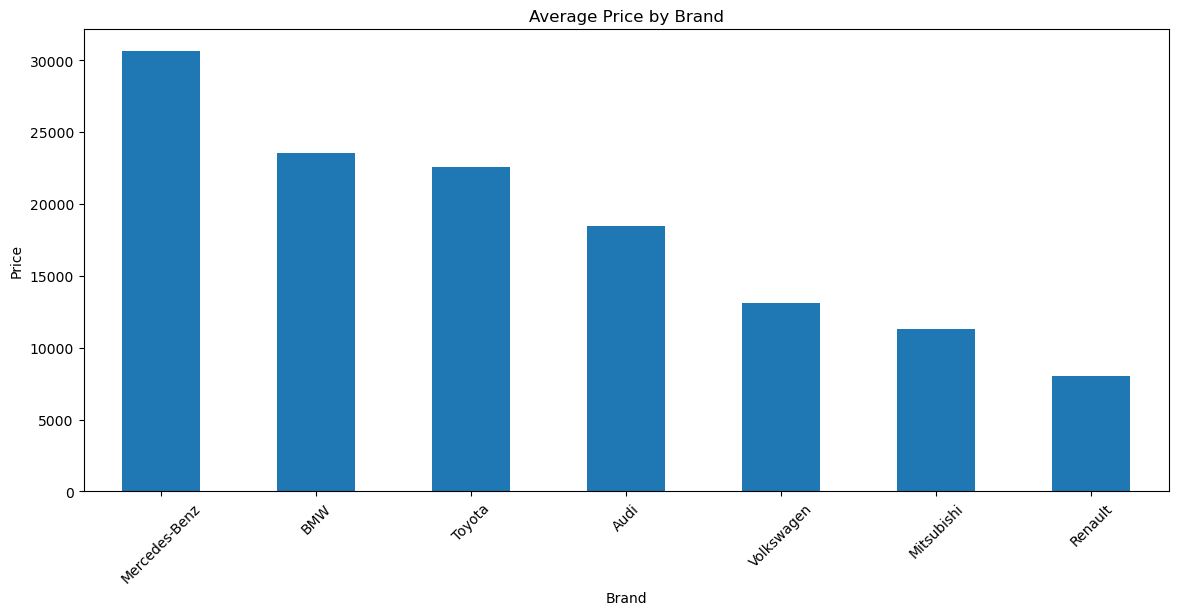

In [6]:
plt.figure(figsize=(14, 6))
df.groupby('Brand')['Price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Price by Brand')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.savefig('brand_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(df.isnull().sum())

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4345 non-null   str    
 1   Price         4173 non-null   float64
 2   Body          4345 non-null   str    
 3   Mileage       4345 non-null   int64  
 4   EngineV       4195 non-null   float64
 5   Engine Type   4345 non-null   str    
 6   Registration  4345 non-null   str    
 7   Year          4345 non-null   int64  
 8   Model         4345 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 305.6 KB


In [9]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import joblib

df = df.dropna(subset=['Price'])

def clip_outliers(df, col):
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)
    return df

for col in ['Mileage', 'EngineV', 'Price']:
    df = clip_outliers(df, col)

df['Car_Age_2026'] = 2026 - df['Year']
df['Mileage_per_Year'] = df['Mileage'] / (df['Car_Age_2026'] + 1)

y = df['Price']
X = df.drop(columns=['Price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.copy()
X_test = X_test.copy()

brand_mean = X_train.join(y_train).groupby('Brand')['Price'].mean()
X_train['Brand_Power'] = X_train['Brand'].map(brand_mean)
X_test['Brand_Power'] = X_test['Brand'].map(brand_mean)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns

num_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

param_grid = {
    'model__n_estimators': [300, 500, 600],
    'model__learning_rate': [0.05, 0.08, 0.09],
    'model__max_depth': [3, 6, 9]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")

tuned_xgb = grid_search.best_estimator_
tuned_xgb_pred = tuned_xgb.predict(X_test)

print(f"R²:   {r2_score(y_test, tuned_xgb_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, tuned_xgb_pred)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, tuned_xgb_pred):.4f}")

joblib.dump(tuned_xgb, 'car_price_model.pkl')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'model__learning_rate': 0.08, 'model__max_depth': 6, 'model__n_estimators': 600}
R²:   0.9268
RMSE: 5492.0638
MAE:  2545.3638


['car_price_model.pkl']

In [10]:
from sklearn.linear_model import LinearRegression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
print(f"Linear Regression R²: {r2_score(y_test, lr_pred):.4f}")
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.4f}")

Linear Regression R²: 0.6739
Linear Regression RMSE: 11595.2579


In [11]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        subsample=0.8, 
        colsample_bytree=0.8, 
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
print(f"XGBoost R²: {r2_score(y_test, xgb_pred):.4f}")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.4f}")

XGBoost R²: 0.9163
XGBoost RMSE: 5874.0743


In [12]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results_data = {
    "Model": [
        "Linear Regression", 
        "XGBoost (Default)",
        "XGBoost (Tuned)"
    ],
    "R²": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, xgb_pred),
        r2_score(y_test, tuned_xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred)),
        np.sqrt(mean_squared_error(y_test, tuned_xgb_pred))
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, xgb_pred),
        mean_absolute_error(y_test, tuned_xgb_pred)
    ]
}

df_results = pd.DataFrame(results_data, index=results_data['Model']).drop(columns=['Model'])

df_results = df_results.round(4)

df_results

,R²,RMSE,MAE
Linear Regression,0.6739,11595.2579,6212.6038
XGBoost (Default),0.9163,5874.0743,2703.8782
XGBoost (Tuned),0.9268,5492.0638,2545.3638


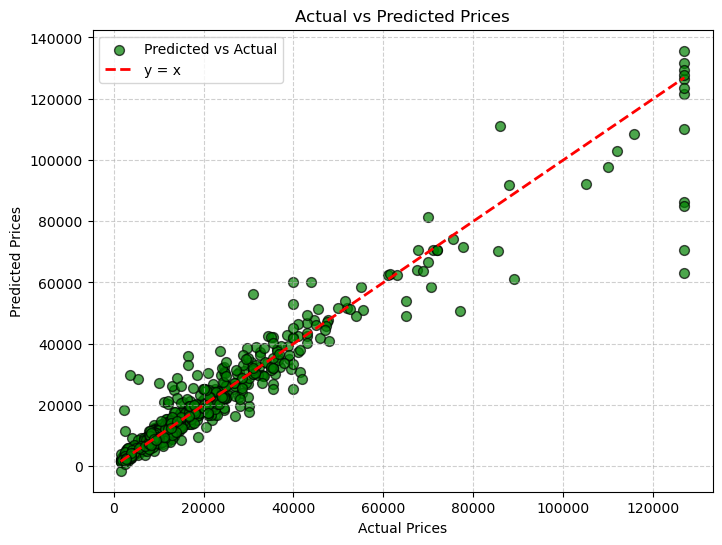

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, tuned_xgb_pred, marker='o', edgecolor='k', alpha=0.7, color='green', label='Predicted vs Actual', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')

plt.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.legend()

plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
df_clean = df.copy()
df_clean.to_csv('car_sales_clean.csv', index=False, float_format='%.2f')